# PCI on Pearl's Desert Traveller

This notebook works through the **desert-traveller puzzle**, a classic test
case for any theory of actual causation, using **PCI** (Probabilistic Causal
Impact). PCI is the responsibility-attribution framework developed in the
companion paper; it reports, for each candidate cause, three numbers in
$[0,1]$ — a *necessity* score, a *sufficiency* score, and their *joint*
combination. The desert-traveller is a good stress test because it is one of
the cases that classical actual-causation accounts find genuinely hard.

## Why this puzzle is hard

A traveller has two enemies who act independently. One **poisons** the water;
the other later **shoots a hole in the canteen** so it drains. The traveller
sets off and dies. Who *caused* the death?

The difficulty is **overdetermination via preemption**. Each enemy's act would
have killed the traveller on its own, so neither looks *necessary*: take away
the poisoner and the empty canteen still kills; take away the shooter and the
cyanide still kills. A naive "but-for" (counterfactual) test therefore clears
*both* suspects — clearly the wrong answer, since the traveller plainly died of
*something*. Yet only one mechanism actually operated: if the traveller drank
before the canteen drained, cyanide killed him (and the dehydration path was
*preempted*); if the canteen drained first, dehydration killed him (and the
poison never got its chance). The hard problem is to say *who is responsible*
in a way that (a) fingers the mechanism that actually operated, (b) does not
let either enemy fully off the hook, and (c) degrades gracefully when a
mechanism is unreliable rather than guaranteed.

## What PCI brings

Pearl's *probability of actual causation* answers this with a **binary**
verdict per noise state — full blame or none. PCI instead reports a **graded**
responsibility score. Across this notebook we show that PCI (1) *agrees* with
Pearl's actual-cause ranking — it points at the operative mechanism — while
(2) giving the dormant cause a small but non-zero share, and (3) tracking how
responsibility *drops* when a causal path is made unreliable. The framework
material and the side-by-side tables this notebook reproduces live in the
paper's Section on the *Probability of Actual Causality*
(`sections/sec7b_paac.tex`); the full model and component specification are in
Appendix `sections/appC_desert.tex`.

We work the basic deterministic case first, then a *weak-poison* variant. For
each example we run the framework's `ThinSearchSampler` and a hand-rolled
enumeration, and check that they agree within Monte Carlo noise — the
hand-rolled version is a transparent reference implementation, so agreement is
evidence that the framework is computing what we claim.

## The story

Two enemies, one traveller.

- **Shooter** ($X$) empties the canteen ($X=1$ when they act).
- **Poisoner** ($P$) puts cyanide in the canteen ($P=1$ when they act).

A single coin $u$ decides the *order*:

- $u = 0$: traveller drank the poisoned water before the canteen was emptied →
  **cyanide killed**.
- $u = 1$: canteen was empty before the traveller could drink →
  **dehydration killed**.

Both enemies acted ($X = P = 1$) and the traveller died ($Y = 1$). PCI's
question: how much responsibility does each enemy bear?

Two intermediate "which path operated" indicators sit in between:

- $c$: cyanide path actually operated (poisoned water was drunk).
- $d$: dehydration path actually operated (drank from empty canteen).

In Scenario A (cyanide killed), factually $c = 1$, $d = 0$.
In Scenario B (dehydration killed), factually $c = 0$, $d = 1$.

The weak-poison variant adds one more piece: a fatality coin $\xi \sim
\mathrm{Bern}(\alpha)$ with $\alpha = 0.1$. Even if the cyanide is drunk,
it only kills with probability $\alpha$. A new mediator $v_C = c \cdot \xi$
records "cyanide *was* fatal".

## The components of PCI

Before we say what we report, we have to say what PCI is averaging over.
A PCI computation has the following moving parts (sec3:451--488):

| Component | What it does | Choice in this notebook |
|---|---|---|
| Suspect set $\mathbf{S}$ | the pool of variables that could plausibly be causes | $\{X, P\}$ |
| Candidate cause sets $\mathbf{C}$ | subsets of $\mathbf{S}$ being interrogated; weighted by $\Gamma$ | singletons $\{X\}$, $\{P\}$ |
| Witness pool $\mathbf{W}$ | context variables that *may* be held fixed | mediators $\{c, d\}$ (basic), $\{c, d, v_C\}$ (weak) |
| Active witness sets $\mathbf{T} \subseteq \mathbf{W}$ | the subset of witnesses pinned in a given pass; weighted by $\Gamma$ | all subsets, cardinality-uniform $\Gamma$ |
| Alternative-value distribution $\Delta$ | what counts as a counterfactually different value for the cause | deterministic $1 \to 0$ |
| Noise distribution $P_{\mathbf{U}}$ | what noise realisations are we averaging over | forensic posterior (point mass at the scenario's noise realisation) |
| Non-cause variables (suspects not in $\mathbf{C}$, mediators not in $\mathbf{T}$) | follow the SCM under the sampled noise; *not* hard-coded | drawn from priors / computed from the SCM |

## What PCI reports — three expectations per cause

In plain terms, for a candidate cause $C$:

- **Necessity** $N_C$ asks: if $C$ had not acted, how often would the
  traveller have survived? High when removing $C$ tends to undo the death.
- **Sufficiency** $S_C$ asks: with $C$ acting as it factually did, how often
  is the death still produced? High when $C$ on its own reliably brings
  about the outcome.
- **Joint** $J_C$ rewards $C$ only when *both* hold in the same draw: removing
  $C$ flips the outcome *and* keeping $C$ sustains it. This is the headline
  responsibility number we read off below.

For each candidate cause $C$ and the factual outcome $y^\star = 1$, PCI's
three quantities are expectations averaging jointly over $\Gamma$
(witness subsets), $\Delta$ (alternative cause values), $P_{\mathbf{U}}$
(noise), and the SCM-driven distribution of non-cause variables. In
compact form:

$$
\begin{aligned}
N_C &= \mathbb{E}_{\Gamma, \Delta, P_{\mathbf{U}}, \text{SCM}} \bigl[\, \mathbb{1}\{Y^n \neq y^\star\} \,\bigr],\\
S_C &= \mathbb{E}_{\Gamma, P_{\mathbf{U}}, \text{SCM}} \bigl[\, \mathbb{1}\{Y^s = y^\star\} \,\bigr],\\
J_C &= \mathbb{E}_{\Gamma, \Delta, P_{\mathbf{U}}, \text{SCM}} \bigl[\, \mathbb{1}\{Y^n \neq y^\star\}\,\mathbb{1}\{Y^s = y^\star\} \,\bigr].
\end{aligned}
$$

Where $Y^n$ is the outcome under the *necessity world* ($\mathrm{do}(C = c')$ with
$c' \sim \Delta$, witnesses in $T$ pinned at factual) and $Y^s$ is the
outcome under the *sufficiency world* ($\mathrm{do}(C = c^\star)$, witnesses in
$T$ pinned at factual). All three are in $[0, 1]$; higher = more attribution.

Concretely, each random draw in the expectation is:

1. Sample noise $\mathbf{u} \sim P_{\mathbf{U}}$ (forensic posterior or prior).
2. Sample a witness subset $T \subseteq \mathbf{W}$ from $\Gamma$ (cardinality-uniform here).
3. Sample an alternative value $c' \sim \Delta$ (deterministic flip here).
4. Compute $Y^n$ and $Y^s$ from the SCM with the indicated interventions;
   any non-cause suspect that's neither in $\mathbf{C}$ nor in $\mathbf{T}$
   is sampled from its prior as part of the SCM trace.
5. Evaluate the indicator on the (binary) outcome.

The *slogan* readings — "necessity = how often does removing $C$ flip
$Y$", "sufficiency = how often does keeping $C$ at factual sustain $Y$" —
are accurate **as long as you remember the averaging is over all five
sources of randomness above, not just over noise**. In particular, the
non-cause suspect is integrated out (drawn from prior); PCI's necessity
and sufficiency are not single counterfactual evaluations but averages
across a population of related counterfactual settings.

## Workflow — when to condition $P_{\mathbf{U}}$ on what

PCI's integration averages over $P_{\mathbf{U}}$. Different questions call
for different choices:

**One pyro model per scenario** with the noise pinned at the
scenario's forensic realisation. `ThinSearchSampler` runs separately on
each model with `batch_size = 1`. The forensic noise sits *above* the
outcome $Y$ in the SCM — we observe mediator-level evidence (post-mortem
cyanide detection, temporal evidence) and pin the noise accordingly. We
do *not* condition on $Y$ itself.

The paper rules out the alternative ("fully conditional") of
conditioning on $Y$ as a downstream-conditioning anti-pattern
(sec3:330--336, sec3:381--387).

## 1. Setup

We import the PCI framework (`pci.explanation`), Pyro for the structural
models, and the usual numerical stack. The `smoke_test` flag (set in CI) only
shrinks sample counts; it does not change any reported logic.

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pyro
import pyro.distributions as dist
import torch

from pci.explanation.regime import condition_on_interventional_regime
from pci.explanation.scores import abs_diff_score
from pci.explanation.searchable import SearchableModel
from pci.explanation.thin_search import ThinSearchSampler

smoke_test = "CI" in os.environ
NUM_TS_SAMPLES = 200 if smoke_test else 8000

warnings.filterwarnings("ignore")
torch.manual_seed(0);

## 2. Basic (deterministic) desert traveller

We start with Pearl's original, fully deterministic version: drinking the
poisoned water is certain to kill, and so is an empty canteen. The only
uncertainty is the *order* of events, carried by the coin $u$. The structural
causal model (SCM) encodes the preemption story directly.

The SCM (Pearl 2nd ed., p.~323):

$$c = P \cdot (u' \vee X'), \qquad d = X \cdot (u \vee P'), \qquad y = c \vee d.$$

Reading the equations:
- $c = 1$ when the poisoner acted *and* (the noise was $u'$, *or* the
  shooter hadn't yet emptied the canteen). I.e., poisoned water gets drunk.
- $d = 1$ when the shooter acted *and* (the noise was $u$, *or* the
  poisoner hadn't yet acted). I.e., the traveller is left with an empty
  canteen.
- $y$ is the OR of the two.

Factual: $X = 1$, $P = 1$, $Y = 1$.
- Scenario A ($u = 0$, cyanide killed): factual mediators $(c, d) = (1, 0)$.
- Scenario B ($u = 1$, dehydration killed): factual mediators $(c, d) = (0, 1)$.

We run PCI under **forensic conditioning**: one pyro model per scenario
with $u$ pinned at the scenario's forensic realisation. `ThinSearchSampler`
runs separately on each model (`batch_size = 1`) and a parallel manual
enumeration uses a point-mass noise distribution at the same realisation.
Framework and manual should agree on all three quantities $N$, $S$, $J$
within Monte Carlo noise.

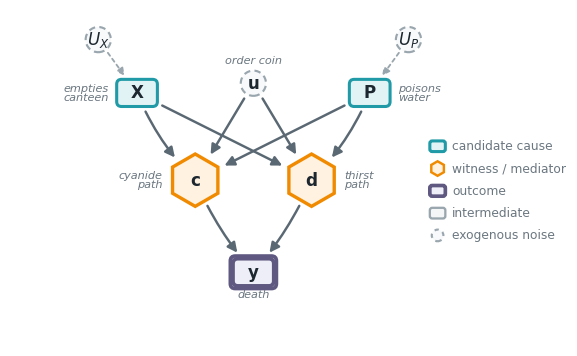

In [1]:
# Causal DAG for the desert-traveller model.
#
# Rendered with the SAME helper that generates the paper figure
# (scripts/make_example_dags.py): single source of truth, so this notebook and
# the paper never drift. The rendering is colour-blind-safe -- each role is
# encoded by SHAPE (box / hexagon / double box / dashed circle) as well as
# colour, and dashed U-circles mark the exogenous noise on each stochastic
# mechanism.
import pathlib
import sys

_p = pathlib.Path.cwd()
for _ in range(8):
    if (_p / "scripts" / "make_example_dags.py").exists():
        sys.path.insert(0, str(_p))
        break
    _p = _p.parent
from scripts.make_example_dags import fig_desert  # noqa: E402

fig, ax = plt.subplots(figsize=(5.8, 4.6))
ax.axis("off")
ax.set_aspect("equal")
fig_desert(ax)
plt.show()

In [2]:
def desert_eqs(X, P, u, c_pin=None, d_pin=None):
    c = c_pin if c_pin is not None else P * max(1 - u, 1 - X)
    d = d_pin if d_pin is not None else X * max(u, 1 - P)
    return c, d, max(c, d)


def dt_manual(cause, world_value, factual_mediators, Y_star):
    """PCI factor on the original DT under the spec above.

    - witness pool {c, d}; cardinality-uniform Gamma over k in {0, 1, 2}
    - non-cause suspect marginalised over Bern(0.5) -- follows the SCM, not pinned
    - noise u from prior Bern(0.5) -- we integrate, not condition
    - world_value = 0           -> necessity (do(C = alternative))
    - world_value = factual    -> sufficiency (do(C = factual))
    """
    f_c, f_d = factual_mediators
    subsets_by_k = {0: [("c", "d")], 1: [("d",), ("c",)], 2: [()]}
    weighted = 0.0
    total = 0.0
    for u in [0, 1]:
        p_u = 0.5
        for subsets in subsets_by_k.values():
            for w_set in subsets:
                prob_T = (1.0 / 3.0) / len(subsets)
                c_pin = f_c if "c" in w_set else None
                d_pin = f_d if "d" in w_set else None
                for other_val in [0, 1]:
                    X_int = world_value if cause == "X" else other_val
                    P_int = world_value if cause == "P" else other_val
                    _, _, Y = desert_eqs(X_int, P_int, u, c_pin=c_pin, d_pin=d_pin)
                    w = p_u * prob_T / 2
                    weighted += w * abs(Y - Y_star)
                    total += w
    return weighted / total

### Workflow

Build one pyro model per scenario with $u$ pinned:

- Scenario A: $u = 0$ (cyanide-in-body + temporal evidence forces this).
- Scenario B: $u = 1$ (no cyanide + canteen-empty evidence).

For each scenario, the framework's `ThinSearchSampler` and a hand-rolled
enumeration run on the same forensic noise; the table prints both side by
side, then the within-scenario sum-normalised share and the per-cause
max-configuration $J$ for absolute-value interpretation.

In [3]:
def make_dt_scenario_model(u_val):
    """Pyro model for the original DT with u pinned at u_val."""

    def _model(kwargs_iterable=None):
        if kwargs_iterable is None:
            kwargs_iterable = [{"observations_dict": None, "n_size": 1}, {}, {}]
        bs = kwargs_iterable[0]["n_size"]
        bl = torch.ones(bs, 1, 1, 2)
        u_tensor = torch.full((bs, 1, 1), u_val, dtype=torch.long)
        u = pyro.deterministic("u", u_tensor, event_dim=0)
        X = pyro.sample("X", dist.Categorical(logits=bl))
        P = pyro.sample("P", dist.Categorical(logits=bl))
        uf, Xf, Pf = u.float(), X.float(), P.float()
        c = pyro.deterministic("c", Pf * torch.maximum(1.0 - uf, 1.0 - Xf), event_dim=0)
        d = pyro.deterministic("d", Xf * torch.maximum(uf, 1.0 - Pf), event_dim=0)
        y = pyro.deterministic("y", torch.maximum(c, d), event_dim=0)
        return {
            "categorical": {"u": u, "X": X, "P": P},
            "continuous": {"c": c, "d": d, "y": y},
        }

    return _model


def make_dt_scenario_factual(u_val, c_val, d_val):
    return {
        "categorical": {
            "u": torch.tensor([[u_val]], dtype=torch.long).view(1, 1, 1),
            "X": torch.tensor([[1]], dtype=torch.long).view(1, 1, 1),
            "P": torch.tensor([[1]], dtype=torch.long).view(1, 1, 1),
        },
        "continuous": {
            "c": torch.tensor([[c_val]], dtype=torch.float).view(1, 1, 1),
            "d": torch.tensor([[d_val]], dtype=torch.float).view(1, 1, 1),
            "y": torch.tensor([[1.0]], dtype=torch.float).view(1, 1, 1),
        },
    }


def dt_manual_with_noise(cause, world_value, factual_mediators, Y_star, u_val):
    """DT PCI factor with u pinned at u_val. Non-cause suspect marginalised;
    cardinality-uniform Gamma over witness subsets of {c, d}."""
    f_c, f_d = factual_mediators
    subsets_by_k = {0: [("c", "d")], 1: [("d",), ("c",)], 2: [()]}
    weighted, total = 0.0, 0.0
    for subsets in subsets_by_k.values():
        for w_set in subsets:
            prob_T = (1.0 / 3.0) / len(subsets)
            c_pin = f_c if "c" in w_set else None
            d_pin = f_d if "d" in w_set else None
            for other_val in [0, 1]:
                X_int = world_value if cause == "X" else other_val
                P_int = world_value if cause == "P" else other_val
                _, _, Y = desert_eqs(X_int, P_int, u_val, c_pin=c_pin, d_pin=d_pin)
                w = prob_T / 2
                weighted += w * abs(Y - Y_star)
                total += w
    return weighted / total


def dt_joint_manual_with_noise(
    cause, factual_mediators, Y_star, factual_cause_value, u_val
):
    f_c, f_d = factual_mediators
    subsets_by_k = {0: [("c", "d")], 1: [("d",), ("c",)], 2: [()]}
    joint, total = 0.0, 0.0
    for subsets in subsets_by_k.values():
        for w_set in subsets:
            prob_T = (1.0 / 3.0) / len(subsets)
            c_pin = f_c if "c" in w_set else None
            d_pin = f_d if "d" in w_set else None
            p_s = 0.0
            for o in [0, 1]:
                X_int = factual_cause_value if cause == "X" else o
                P_int = factual_cause_value if cause == "P" else o
                _, _, Y_s = desert_eqs(X_int, P_int, u_val, c_pin=c_pin, d_pin=d_pin)
                p_s += 0.5 * (1.0 if Y_s == Y_star else 0.0)
            p_n = 0.0
            for o in [0, 1]:
                X_int = 0 if cause == "X" else o
                P_int = 0 if cause == "P" else o
                _, _, Y_n = desert_eqs(X_int, P_int, u_val, c_pin=c_pin, d_pin=d_pin)
                p_n += 0.5 * (1.0 if Y_n != Y_star else 0.0)
            joint += prob_T * p_s * p_n
            total += prob_T
    return joint / total


dt_scenario_specs = [
    ("A: cyanide killed", 0, 1.0, 0.0),
    ("B: dehydration killed", 1, 0.0, 1.0),
]

dt_forensic_framework_rows = []
dt_forensic_manual_rows = []
for label, u_val, c_val, d_val in dt_scenario_specs:
    scen_model = make_dt_scenario_model(u_val)
    scen_searchable = SearchableModel(
        structured_model=scen_model,
        sites_of_interest=["u", "X", "P", "c", "d", "y"],
        suspects=["X", "P"],
        deterministic_sites=["u", "c", "d", "y"],
        shared_noise_sites=[],
        outcome_variable="y",
        witness_sites=["c", "d"],
    )
    scen_sampler = ThinSearchSampler(
        structured_model=scen_searchable,
        conditioned_alternatives=False,
        factual_exclusion=True,
        max_antecedents=1,
        max_witnesses_dropped=2,
    )
    scen_fs = make_dt_scenario_factual(u_val, c_val, d_val)
    scen_results = scen_sampler.sample(scen_fs, num_samples=NUM_TS_SAMPLES)
    for cause_letter, cause_name in [("X", "shooter"), ("P", "poisoner")]:
        cond = condition_on_interventional_regime(
            results_dictionary=scen_results,  # type: ignore[arg-type]  # ThinSearchResult duck-types as dict
            reference_variable_names=[cause_letter],
            antecedent_regimes={cause_letter: True},
        )
        sc = abs_diff_score(
            factual_outcomes=scen_fs["continuous"]["y"],
            suff_outcomes=cond["regime_sufficiency"]["y"].detach(),
            nec_outcomes=cond["regime_necessity"]["y"].detach(),
        )
        N_f = sc["nec"][:, :, 0, 0].nanmean(dim=0).tolist()[0]
        S_f = 1.0 - abs(sc["suff"][:, :, 0, 0].nanmean(dim=0).tolist()[0])
        y_s = cond["regime_sufficiency"]["y"][:, 0, 0, 0].detach()
        y_n = cond["regime_necessity"]["y"][:, 0, 0, 0].detach()
        valid = ~(torch.isnan(y_s) | torch.isnan(y_n))
        J_f = ((y_s[valid] == 1.0).float() * (y_n[valid] != 1.0).float()).mean().item()
        dt_forensic_framework_rows.append(
            (label, cause_letter, cause_name, N_f, S_f, J_f)
        )
        # Manual
        N_m = dt_manual_with_noise(cause_letter, 0, (c_val, d_val), 1.0, u_val)
        S_m = 1.0 - dt_manual_with_noise(cause_letter, 1, (c_val, d_val), 1.0, u_val)
        J_m = dt_joint_manual_with_noise(cause_letter, (c_val, d_val), 1.0, 1, u_val)
        dt_forensic_manual_rows.append((label, cause_letter, cause_name, N_m, S_m, J_m))

print("Original DT, forensic-conditioned reading -- framework vs manual:")
print(
    f"{'Scenario':>26}  {'cause':>16}  {'N fwk':>8}  {'N man':>8}  {'S fwk':>8}  {'S man':>8}  {'J fwk':>8}  {'J man':>8}"
)
for fwk, man in zip(dt_forensic_framework_rows, dt_forensic_manual_rows):
    label, letter, name = fwk[0], fwk[1], fwk[2]
    label_cause = name + " (" + letter + ")"
    print(
        f"{label:>26}  {label_cause:>16}  "
        f"{fwk[3]:>8.4f}  {man[3]:>8.4f}  {fwk[4]:>8.4f}  {man[4]:>8.4f}  "
        f"{fwk[5]:>8.4f}  {man[5]:>8.4f}"
    )


# --- Sum-normalised share + per-cause "max-configuration" (best-witness) J ---
print()
print("Within-scenario J normalisation (each cause's share of joint attribution):")
print(f"{'Scenario':>26}  {'cause':>16}  {'J':>8}  {'share':>8}")
scenarios_seen: dict[str, list[tuple]] = {}
for row in dt_forensic_manual_rows:
    label = row[0]
    scenarios_seen.setdefault(label, []).append(row)
for label, rows in scenarios_seen.items():
    total = sum(r[5] for r in rows)
    for r in rows:
        label_cause = r[2] + " (" + r[1] + ")"
        share = r[5] / total if total > 0 else 0
        print(f"{label:>26}  {label_cause:>16}  {r[5]:>8.4f}  {share:>8.2%}")

# Per-witness maximum J for each cause (across the four witness subsets)
print()
print("Per-cause max-configuration J (best witness in this scenario):")
print(
    f"{'Scenario':>26}  {'cause':>16}  {'J avg':>8}  {'J max-cfg':>10}  {'avg/max':>8}"
)
subsets_list = [(), ("c",), ("d",), ("c", "d")]
for label, u_val, c_val, d_val in dt_scenario_specs:
    for cause_letter, cause_name in [("X", "shooter"), ("P", "poisoner")]:
        # Find J_avg (already in dt_forensic_manual_rows)
        J_avg = next(
            r[5]
            for r in dt_forensic_manual_rows
            if r[0] == label and r[1] == cause_letter
        )
        # Compute per-T joint
        per_T = []
        for w_set in subsets_list:
            c_pin = c_val if "c" in w_set else None
            d_pin = d_val if "d" in w_set else None
            p_s, p_n = 0.0, 0.0
            for o in [0, 1]:
                X_s = 1 if cause_letter == "X" else o
                P_s = 1 if cause_letter == "P" else o
                _, _, Ys = desert_eqs(X_s, P_s, u_val, c_pin=c_pin, d_pin=d_pin)
                p_s += 0.5 * (1.0 if Ys == 1 else 0.0)
                X_n = 0 if cause_letter == "X" else o
                P_n = 0 if cause_letter == "P" else o
                _, _, Yn = desert_eqs(X_n, P_n, u_val, c_pin=c_pin, d_pin=d_pin)
                p_n += 0.5 * (1.0 if Yn != 1 else 0.0)
            per_T.append(p_s * p_n)
        J_max = max(per_T)
        ratio = J_avg / J_max if J_max > 0 else 0
        label_cause = cause_name + " (" + cause_letter + ")"
        print(
            f"{label:>26}  {label_cause:>16}  {J_avg:>8.4f}  {J_max:>10.4f}  {ratio:>8.2%}"
        )

  0%|          | 0/8000 [00:00<?, ?it/s]

  2%|▏         | 164/8000 [00:00<00:04, 1638.07it/s]

  4%|▍         | 328/8000 [00:00<00:04, 1624.55it/s]

  6%|▌         | 492/8000 [00:00<00:04, 1631.05it/s]

  8%|▊         | 656/8000 [00:00<00:04, 1493.98it/s]

...

 95%|█████████▍| 7566/8000 [00:05<00:00, 1266.19it/s]

 96%|█████████▋| 7720/8000 [00:05<00:00, 1337.09it/s]

 98%|█████████▊| 7870/8000 [00:05<00:00, 1380.80it/s]

100%|██████████| 8000/8000 [00:05<00:00, 1378.48it/s]

Original DT, forensic-conditioned reading -- framework vs manual:
                  Scenario             cause     N fwk     N man     S fwk     S man     J fwk     J man
         A: cyanide killed       shooter (X)    0.2696    0.2500    0.9113    0.9167    0.2234    0.2083
         A: cyanide killed      poisoner (P)    0.3348    0.3333    1.0000    1.0000    0.3348    0.3333
     B: dehydration killed       shooter (X)    0.3241    0.3333    1.0000    1.0000    0.3241    0.3333
     B: dehydration killed      poisoner (P)    0.2537    0.2500    0.9077    0.9167    0.2091    0.2083

Within-scenario J normalisation (each cause's share of joint attribution):
                  Scenario             cause         J     share
         A: cyanide killed       shooter (X)    0.2083    38.46%
         A: cyanide killed      poisoner (P)    0.3333    61.54%
     B: dehydration killed       shooter (X)    0.3333    61.54%
     B: dehydration killed      poisoner (P)    0.2083    38.46%

Per-cau

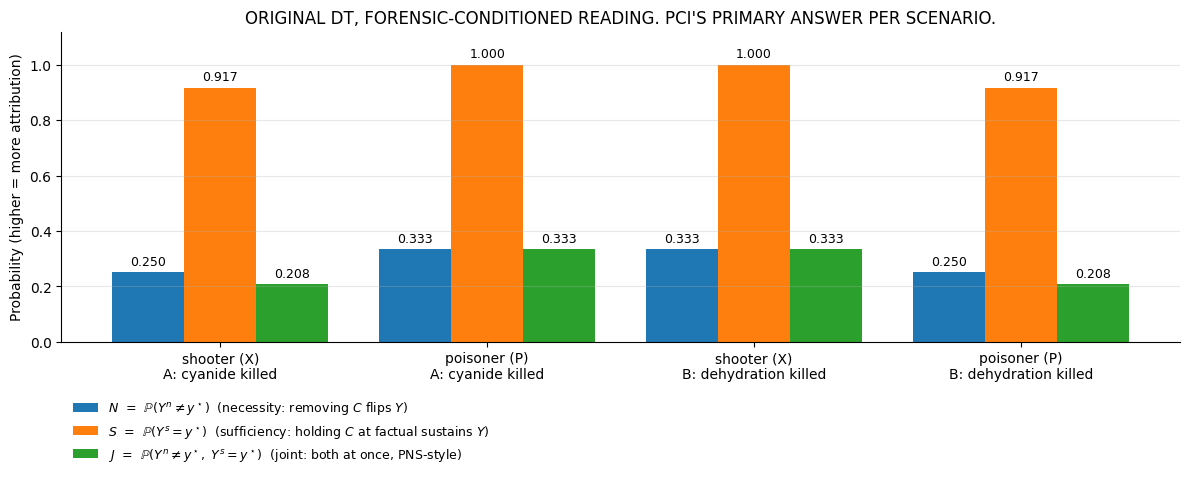

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
group_labels = [
    name + " (" + letter + ")\n" + label
    for label, letter, name, *_ in dt_forensic_manual_rows
]
x_pos = np.arange(len(dt_forensic_manual_rows))
width = 0.27
N_vals = [r[3] for r in dt_forensic_manual_rows]
S_vals = [r[4] for r in dt_forensic_manual_rows]
J_vals = [r[5] for r in dt_forensic_manual_rows]
ax.bar(
    x_pos - width,
    N_vals,
    width,
    label=r"$N$  =  $\mathbb{P}(Y^n \neq y^\star)$  (necessity: removing $C$ flips $Y$)",
    color="#1f77b4",
)
ax.bar(
    x_pos,
    S_vals,
    width,
    label=r"$S$  =  $\mathbb{P}(Y^s = y^\star)$  (sufficiency: holding $C$ at factual sustains $Y$)",
    color="#ff7f0e",
)
ax.bar(
    x_pos + width,
    J_vals,
    width,
    label=r"$J$  =  $\mathbb{P}(Y^n \neq y^\star,\ Y^s = y^\star)$  (joint: both at once, PNS-style)",
    color="#2ca02c",
)
ax.set_xticks(x_pos)
ax.set_xticklabels(group_labels, fontsize=10)
ax.set_ylabel("Probability (higher = more attribution)")
ax.set_title(
    "ORIGINAL DT, FORENSIC-CONDITIONED READING. PCI'S PRIMARY ANSWER PER SCENARIO."
)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=9, loc="upper left", bbox_to_anchor=(0.0, -0.15), frameon=False)
ax.grid(axis="y", alpha=0.3)
for container_idx, vals in enumerate([N_vals, S_vals, J_vals]):
    for rect, v in zip(ax.containers[container_idx], vals):
        ax.annotate(
            f"{v:.3f}",
            xy=(rect.get_x() + rect.get_width() / 2, v),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

**Reading (basic DT).** Framework and manual agree on all three
quantities within Monte Carlo noise. PCI's joint responsibility correctly
points to the **operative cause** in each scenario:

| Scenario | $J_{\text{shooter}}$ | $J_{\text{poisoner}}$ | Verdict |
|---|---|---|---|
| A: cyanide killed | $5/24 \approx 0.21$ | $\mathbf{1/3 \approx 0.33}$ | poisoner |
| B: dehydration killed | $\mathbf{1/3 \approx 0.33}$ | $5/24 \approx 0.21$ | shooter |

**Interpreting these absolute values.**

- **Sum-normalised share** (within each scenario, each cause's share of joint
  attribution): the operative cause holds ~62% of the joint responsibility,
  the dormant one ~38%. Even the "wrong" cause has some attribution
  because removing the shooter at $u=0$ does flip $Y$ in some
  witness/coin configurations (when $P$ from prior happens to land on 0).
- **Max-configuration ratio**: one of the four witness setups gives the
  operative cause $J = 1$. For the poisoner in A it is $T = \{d\}$: pin the
  dormant dehydration mediator, and removing the poisoner flips $Y$ every
  time while holding him at factual sustains it. That setup carries
  $\Gamma$-weight $1/6$, so it contributes $1/6$ of the total; the empty
  witness set contributes the other $1/6$, at $J = 0.5$. The two together
  make the $1/3$.

So $J = 1/3$ is not a low number on this scale. The dormant cause never
exceeds $J = 0.5$ in any single setup, while the operative cause reaches
the ceiling of $1$ in the one setup that isolates its path.

## 3. Weak-poison variant

The basic case shows PCI recovering Pearl's ranking. But because both paths
were deterministic, Pearl's binary verdict and PCI's ranking necessarily
agree. To see what the *graded* score buys us, we now break the symmetry: make
the cyanide path **unreliable** while keeping dehydration certain. Pearl's
binary indicator is blind to this change (it still saturates at $1$ for the
operative cause), but PCI should register that an unreliable killer deserves
less responsibility — even in the scenario where its poison did the killing.

Same SCM with one addition: a fatality coin $\xi \sim \mathrm{Bern}(\alpha)$
with $\alpha = 0.1$ gating the cyanide path:

$$c = P (u' \vee X'), \quad v_C = c \cdot \xi, \quad
  d = X (u \vee P'), \quad y = v_C \vee d.$$

$c$ still records "poisoned water drunk"; $v_C$ is the new mediator
recording "cyanide *was* fatal" — drinking the cyanide only kills when
$\xi$ also fires.

Two factual scenarios under the same observation $X = P = 1$, $Y = 1$:

- Scenario A — cyanide killed: forensic gives $u = 0$ (drank early) and
  $v_C = 1$ (post-mortem cyanide detected); the structural equation
  $v_C = c \cdot \xi$ then forces $\xi = 1$. Factual mediators
  $(c, v_C, d) = (1, 1, 0)$.
- Scenario B — dehydration killed: forensic gives $u = 1$ (canteen empty
  before drinking); $v_C = 0$ since cyanide path dormant. We take
  $\xi = 0$ as a representative point mass.

We run PCI under forensic conditioning: one pyro model per scenario with
$(u, \xi)$ pinned at the scenario's forensic realisation. Framework and
manual run side by side.

In [5]:
ALPHA = 0.1


def weak_poison_eqs(X, P, u, xi, c_pin=None, d_pin=None, V_C_pin=None):
    c = c_pin if c_pin is not None else P * max(1 - u, 1 - X)
    d = d_pin if d_pin is not None else X * max(u, 1 - P)
    V_C = V_C_pin if V_C_pin is not None else c * xi
    return c, d, V_C, max(V_C, d)


def wp_manual(cause, world_value, factual_mediators, Y_star):
    """PCI factor on the weak-poison DT under the spec above.

    - witness pool {c, d, V_C}; cardinality-uniform Gamma over k in {0, 1, 2, 3}
    - non-cause suspect marginalised over Bern(0.5)
    - noise (u, xi) from priors Bern(0.5) x Bern(alpha) -- we integrate, not condition on Y
    """
    f_c, f_d, f_V_C = factual_mediators
    subsets_by_k = {
        0: [("c", "V_C", "d")],
        1: [("V_C", "d"), ("c", "d"), ("c", "V_C")],
        2: [("d",), ("V_C",), ("c",)],
        3: [()],
    }
    weighted = 0.0
    total = 0.0
    for u in [0, 1]:
        for xi in [0, 1]:
            p_noise = 0.5 * (ALPHA if xi == 1 else (1 - ALPHA))
            for subsets in subsets_by_k.values():
                for w_set in subsets:
                    prob_T = 0.25 / len(subsets)
                    c_pin = f_c if "c" in w_set else None
                    d_pin = f_d if "d" in w_set else None
                    V_C_pin = f_V_C if "V_C" in w_set else None
                    for other_val in [0, 1]:
                        X_int = world_value if cause == "X" else other_val
                        P_int = world_value if cause == "P" else other_val
                        _, _, _, Y = weak_poison_eqs(
                            X_int,
                            P_int,
                            u,
                            xi,
                            c_pin=c_pin,
                            d_pin=d_pin,
                            V_C_pin=V_C_pin,
                        )
                        w = p_noise * prob_T / 2
                        weighted += w * abs(Y - Y_star)
                        total += w
    return weighted / total

### Workflow

Build one pyro model per scenario with $(u, \xi)$ pinned:

- Scenario A: $u = 0$, $\xi = 1$.
- Scenario B: $u = 1$, $\xi = 0$.

Each scenario's framework run and a parallel manual enumeration use the
same forensic noise; the table prints both side by side, then sum-
normalised share and per-cause max-configuration $J$.

Why these forensic posteriors don't leak the outcome: each conditions on
mediator-level observations (cyanide-in-body or its absence, plus temporal
evidence) that sit *above* $Y$ in the SCM. We never condition on $Y = 1$
directly — sec3:330--336 / sec3:381--387 of the paper rule that out as the
"fully conditional" anti-pattern.

In [6]:
# --- Scenario-specific framework runs with forensic-conditioned noise ---
# Build a pyro model per scenario that hard-codes the forensic noise realisation.
# Then run ThinSearchSampler separately, batch_size=1 per scenario.


def make_scenario_model(u_val, xi_val):
    """Return a pyro model where u and xi are fixed at the scenario's forensic
    realisation. All other roots (X, P) sample from priors as usual."""

    def _model(kwargs_iterable=None):
        if kwargs_iterable is None:
            kwargs_iterable = [{"observations_dict": None, "n_size": 1}, {}, {}]
        bs = kwargs_iterable[0]["n_size"]
        bl = torch.ones(bs, 1, 1, 2)
        # Forensic noise pinned: use deterministic sites with the forensic values
        u_tensor = torch.full((bs, 1, 1), u_val, dtype=torch.long)
        xi_tensor = torch.full((bs, 1, 1), xi_val, dtype=torch.long)
        u = pyro.deterministic("u", u_tensor, event_dim=0)
        xi = pyro.deterministic("xi", xi_tensor, event_dim=0)
        X = pyro.sample("X", dist.Categorical(logits=bl))
        P = pyro.sample("P", dist.Categorical(logits=bl))
        uf, Xf, Pf, xif = u.float(), X.float(), P.float(), xi.float()
        c = pyro.deterministic("c", Pf * torch.maximum(1.0 - uf, 1.0 - Xf), event_dim=0)
        V_C = pyro.deterministic("V_C", c * xif, event_dim=0)
        d = pyro.deterministic("d", Xf * torch.maximum(uf, 1.0 - Pf), event_dim=0)
        y = pyro.deterministic("y", torch.maximum(V_C, d), event_dim=0)
        return {
            "categorical": {"u": u, "X": X, "P": P, "xi": xi},
            "continuous": {"c": c, "V_C": V_C, "d": d, "y": y},
        }

    return _model


def make_scenario_factual(u_val, xi_val, c_val, V_C_val, d_val):
    return {
        "categorical": {
            "u": torch.tensor([[u_val]], dtype=torch.long).view(1, 1, 1),
            "X": torch.tensor([[1]], dtype=torch.long).view(1, 1, 1),
            "P": torch.tensor([[1]], dtype=torch.long).view(1, 1, 1),
            "xi": torch.tensor([[xi_val]], dtype=torch.long).view(1, 1, 1),
        },
        "continuous": {
            "c": torch.tensor([[c_val]], dtype=torch.float).view(1, 1, 1),
            "V_C": torch.tensor([[V_C_val]], dtype=torch.float).view(1, 1, 1),
            "d": torch.tensor([[d_val]], dtype=torch.float).view(1, 1, 1),
            "y": torch.tensor([[1.0]], dtype=torch.float).view(1, 1, 1),
        },
    }


# Build the two scenario-specific samplers
scenario_specs = [
    ("A: cyanide killed", 0, 1, 1.0, 1.0, 0.0),  # (u, xi, c, V_C, d)
    ("B: dehydration killed", 1, 0, 0.0, 0.0, 1.0),
]

forensic_framework_rows = []
for label, u_val, xi_val, c_val, V_C_val, d_val in scenario_specs:
    scen_model = make_scenario_model(u_val, xi_val)
    scen_searchable = SearchableModel(
        structured_model=scen_model,
        sites_of_interest=["u", "X", "P", "xi", "c", "V_C", "d", "y"],
        suspects=["X", "P"],
        deterministic_sites=[
            "u",
            "xi",
            "c",
            "V_C",
            "d",
            "y",
        ],  # u, xi are now deterministic too
        shared_noise_sites=[],  # noise already fixed in the model
        outcome_variable="y",
        witness_sites=["c", "V_C", "d"],
    )
    scen_sampler = ThinSearchSampler(
        structured_model=scen_searchable,
        conditioned_alternatives=False,
        factual_exclusion=True,
        max_antecedents=1,
        max_witnesses_dropped=3,
    )
    scen_fs = make_scenario_factual(u_val, xi_val, c_val, V_C_val, d_val)
    scen_results = scen_sampler.sample(scen_fs, num_samples=NUM_TS_SAMPLES)
    for cause_letter, cause_name in [("X", "shooter"), ("P", "poisoner")]:
        cond = condition_on_interventional_regime(
            results_dictionary=scen_results,  # type: ignore[arg-type]  # ThinSearchResult duck-types as dict
            reference_variable_names=[cause_letter],
            antecedent_regimes={cause_letter: True},
        )
        sc = abs_diff_score(
            factual_outcomes=scen_fs["continuous"]["y"],
            suff_outcomes=cond["regime_sufficiency"]["y"].detach(),
            nec_outcomes=cond["regime_necessity"]["y"].detach(),
        )
        N_f = sc["nec"][:, :, 0, 0].nanmean(dim=0).tolist()[0]
        S_f = 1.0 - abs(sc["suff"][:, :, 0, 0].nanmean(dim=0).tolist()[0])
        y_s = cond["regime_sufficiency"]["y"][:, 0, 0, 0].detach()
        y_n = cond["regime_necessity"]["y"][:, 0, 0, 0].detach()
        valid = ~(torch.isnan(y_s) | torch.isnan(y_n))
        J_f = ((y_s[valid] == 1.0).float() * (y_n[valid] != 1.0).float()).mean().item()
        forensic_framework_rows.append((label, cause_letter, cause_name, N_f, S_f, J_f))


# --- Manual under same forensic conditioning ---
def wp_manual_with_noise(cause, world_value, factual_mediators, Y_star, noise_dist):
    f_c, f_d, f_V_C = factual_mediators
    subsets_by_k = {
        0: [("c", "V_C", "d")],
        1: [("V_C", "d"), ("c", "d"), ("c", "V_C")],
        2: [("d",), ("V_C",), ("c",)],
        3: [()],
    }
    weighted, total = 0.0, 0.0
    for noise_tuple, p_noise in noise_dist:
        u, xi = noise_tuple
        for subsets in subsets_by_k.values():
            for w_set in subsets:
                prob_T = 0.25 / len(subsets)
                c_pin = f_c if "c" in w_set else None
                d_pin = f_d if "d" in w_set else None
                V_C_pin = f_V_C if "V_C" in w_set else None
                for other_val in [0, 1]:
                    X_int = world_value if cause == "X" else other_val
                    P_int = world_value if cause == "P" else other_val
                    _, _, _, Y = weak_poison_eqs(
                        X_int,
                        P_int,
                        u,
                        xi,
                        c_pin=c_pin,
                        d_pin=d_pin,
                        V_C_pin=V_C_pin,
                    )
                    w = p_noise * prob_T / 2
                    weighted += w * abs(Y - Y_star)
                    total += w
    return weighted / total


def wp_joint_with_noise(
    cause, factual_mediators, Y_star, factual_cause_value, noise_dist
):
    f_c, f_d, f_V_C = factual_mediators
    subsets_by_k = {
        0: [("c", "V_C", "d")],
        1: [("V_C", "d"), ("c", "d"), ("c", "V_C")],
        2: [("d",), ("V_C",), ("c",)],
        3: [()],
    }
    joint, total = 0.0, 0.0
    for noise_tuple, p_noise in noise_dist:
        u, xi = noise_tuple
        for subsets in subsets_by_k.values():
            for w_set in subsets:
                prob_T = 0.25 / len(subsets)
                c_pin = f_c if "c" in w_set else None
                d_pin = f_d if "d" in w_set else None
                V_C_pin = f_V_C if "V_C" in w_set else None
                p_s = 0.0
                for o in [0, 1]:
                    X_int = factual_cause_value if cause == "X" else o
                    P_int = factual_cause_value if cause == "P" else o
                    _, _, _, Y_s = weak_poison_eqs(
                        X_int, P_int, u, xi, c_pin=c_pin, d_pin=d_pin, V_C_pin=V_C_pin
                    )
                    p_s += 0.5 * (1.0 if Y_s == Y_star else 0.0)
                p_n = 0.0
                for o in [0, 1]:
                    X_int = 0 if cause == "X" else o
                    P_int = 0 if cause == "P" else o
                    _, _, _, Y_n = weak_poison_eqs(
                        X_int, P_int, u, xi, c_pin=c_pin, d_pin=d_pin, V_C_pin=V_C_pin
                    )
                    p_n += 0.5 * (1.0 if Y_n != Y_star else 0.0)
                joint += p_noise * prob_T * p_s * p_n
                total += p_noise * prob_T
    return joint / total


forensic_A_dist = [((0, 1), 1.0)]  # Scenario A forensic: u=0, xi=1
forensic_B_dist = [((1, 0), 1.0)]  # Scenario B forensic: u=1, xi=0

forensic_manual_rows = []
for label, fmed, noise in [
    ("A: cyanide killed", (1.0, 0.0, 1.0), forensic_A_dist),
    ("B: dehydration killed", (0.0, 1.0, 0.0), forensic_B_dist),
]:
    for cause_letter, cause_name in [("X", "shooter"), ("P", "poisoner")]:
        N = wp_manual_with_noise(cause_letter, 0, fmed, 1.0, noise)
        S = 1.0 - wp_manual_with_noise(cause_letter, 1, fmed, 1.0, noise)
        J = wp_joint_with_noise(cause_letter, fmed, 1.0, 1, noise)
        forensic_manual_rows.append((label, cause_letter, cause_name, N, S, J))


# --- Print comparison ---
print("Per-scenario reading (forensic-conditioned noise) -- framework vs manual:")
print(
    f"{'Scenario':>26}  {'cause':>16}  {'N fwk':>8}  {'N man':>8}  {'S fwk':>8}  {'S man':>8}  {'J fwk':>8}  {'J man':>8}"
)
for fwk, man in zip(forensic_framework_rows, forensic_manual_rows):
    assert fwk[0] == man[0] and fwk[1] == man[1]
    label, letter, name = fwk[0], fwk[1], fwk[2]
    label_cause = name + " (" + letter + ")"
    print(
        f"{label:>26}  {label_cause:>16}  "
        f"{fwk[3]:>8.4f}  {man[3]:>8.4f}  {fwk[4]:>8.4f}  {man[4]:>8.4f}  "
        f"{fwk[5]:>8.4f}  {man[5]:>8.4f}"
    )


# --- Sum-normalised share + per-cause max-configuration J ---
print()
print("Within-scenario J normalisation (each cause's share of joint attribution):")
print(f"{'Scenario':>26}  {'cause':>16}  {'J':>8}  {'share':>8}")
scenarios_seen_wp: dict[str, list[tuple]] = {}
for row in forensic_manual_rows:
    scenarios_seen_wp.setdefault(row[0], []).append(row)
for label, rows in scenarios_seen_wp.items():
    total = sum(r[5] for r in rows)
    for r in rows:
        label_cause = r[2] + " (" + r[1] + ")"
        share = r[5] / total if total > 0 else 0
        print(f"{label:>26}  {label_cause:>16}  {r[5]:>8.4f}  {share:>8.2%}")

# Per-cause max-configuration J (best-witness ratio) for weak-poison
print()
print("Per-cause max-configuration J (best witness in this scenario):")
print(
    f"{'Scenario':>26}  {'cause':>16}  {'J avg':>8}  {'J max-cfg':>10}  {'avg/max':>8}"
)
wp_subsets_list = []
import itertools as _it

for r in range(0, 4):  # type: ignore[assignment]  # loop counter reuses tuple-typed name r
    wp_subsets_list.extend(_it.combinations(["c", "d", "V_C"], r))  # type: ignore[call-overload]  # r is int at runtime
for label, fmed, noise in [
    ("A: cyanide killed", (1.0, 0.0, 1.0), forensic_A_dist),
    ("B: dehydration killed", (0.0, 1.0, 0.0), forensic_B_dist),
]:
    f_c, f_d, f_V_C = fmed
    for cause_letter, cause_name in [("X", "shooter"), ("P", "poisoner")]:
        J_avg = next(
            r[5] for r in forensic_manual_rows if r[0] == label and r[1] == cause_letter
        )
        per_T = []
        for w_set in wp_subsets_list:
            c_pin = f_c if "c" in w_set else None
            d_pin = f_d if "d" in w_set else None
            V_C_pin = f_V_C if "V_C" in w_set else None
            for noise_tuple, p_noise in noise:
                u, xi = noise_tuple
                p_s, p_n = 0.0, 0.0
                for o in [0, 1]:
                    X_s = 1 if cause_letter == "X" else o
                    P_s = 1 if cause_letter == "P" else o
                    _, _, _, Ys = weak_poison_eqs(
                        X_s, P_s, u, xi, c_pin=c_pin, d_pin=d_pin, V_C_pin=V_C_pin
                    )
                    p_s += 0.5 * (1.0 if Ys == 1 else 0.0)
                    X_n = 0 if cause_letter == "X" else o
                    P_n = 0 if cause_letter == "P" else o
                    _, _, _, Yn = weak_poison_eqs(
                        X_n, P_n, u, xi, c_pin=c_pin, d_pin=d_pin, V_C_pin=V_C_pin
                    )
                    p_n += 0.5 * (1.0 if Yn != 1 else 0.0)
                per_T.append(p_noise * p_s * p_n)
        # max here is over witness subsets after summing noise contribution
        # (per_T entries are per (T, noise_state) so we group by T)
        # since each T appears in multiple noise rows, sum per T
        # rebuild grouped by T
        per_T_grouped = []
        for w_set in wp_subsets_list:
            c_pin = f_c if "c" in w_set else None
            d_pin = f_d if "d" in w_set else None
            V_C_pin = f_V_C if "V_C" in w_set else None
            joint_at_T = 0.0
            for noise_tuple, p_noise in noise:
                u, xi = noise_tuple
                p_s, p_n = 0.0, 0.0
                for o in [0, 1]:
                    X_s = 1 if cause_letter == "X" else o
                    P_s = 1 if cause_letter == "P" else o
                    _, _, _, Ys = weak_poison_eqs(
                        X_s, P_s, u, xi, c_pin=c_pin, d_pin=d_pin, V_C_pin=V_C_pin
                    )
                    p_s += 0.5 * (1.0 if Ys == 1 else 0.0)
                    X_n = 0 if cause_letter == "X" else o
                    P_n = 0 if cause_letter == "P" else o
                    _, _, _, Yn = weak_poison_eqs(
                        X_n, P_n, u, xi, c_pin=c_pin, d_pin=d_pin, V_C_pin=V_C_pin
                    )
                    p_n += 0.5 * (1.0 if Yn != 1 else 0.0)
                joint_at_T += p_noise * p_s * p_n
            per_T_grouped.append(joint_at_T)
        J_max = max(per_T_grouped)
        ratio = J_avg / J_max if J_max > 0 else 0
        label_cause = cause_name + " (" + cause_letter + ")"
        print(
            f"{label:>26}  {label_cause:>16}  {J_avg:>8.4f}  {J_max:>10.4f}  {ratio:>8.2%}"
        )

  0%|          | 0/8000 [00:00<?, ?it/s]

  2%|▏         | 129/8000 [00:00<00:06, 1286.91it/s]

  3%|▎         | 270/8000 [00:00<00:05, 1353.76it/s]

  5%|▌         | 406/8000 [00:00<00:05, 1339.69it/s]

  7%|▋         | 540/8000 [00:00<00:06, 1184.90it/s]

...

 95%|█████████▌| 7600/8000 [00:05<00:00, 1339.14it/s]

 97%|█████████▋| 7739/8000 [00:05<00:00, 1354.09it/s]

 98%|█████████▊| 7875/8000 [00:06<00:00, 1276.25it/s]

100%|██████████| 8000/8000 [00:06<00:00, 1298.41it/s]

Per-scenario reading (forensic-conditioned noise) -- framework vs manual:
                  Scenario             cause     N fwk     N man     S fwk     S man     J fwk     J man
         A: cyanide killed       shooter (X)    0.1629    0.1667    0.9598    0.9583    0.1457    0.1458
         A: cyanide killed      poisoner (P)    0.2103    0.2083    1.0000    1.0000    0.2103    0.2083
     B: dehydration killed       shooter (X)    0.4731    0.5000    1.0000    1.0000    0.4731    0.5000
     B: dehydration killed      poisoner (P)    0.2619    0.2500    0.7484    0.7500    0.1303    0.1250

Within-scenario J normalisation (each cause's share of joint attribution):
                  Scenario             cause         J     share
         A: cyanide killed       shooter (X)    0.1458    41.18%
         A: cyanide killed      poisoner (P)    0.2083    58.82%
     B: dehydration killed       shooter (X)    0.5000    80.00%
     B: dehydration killed      poisoner (P)    0.1250    20.00%


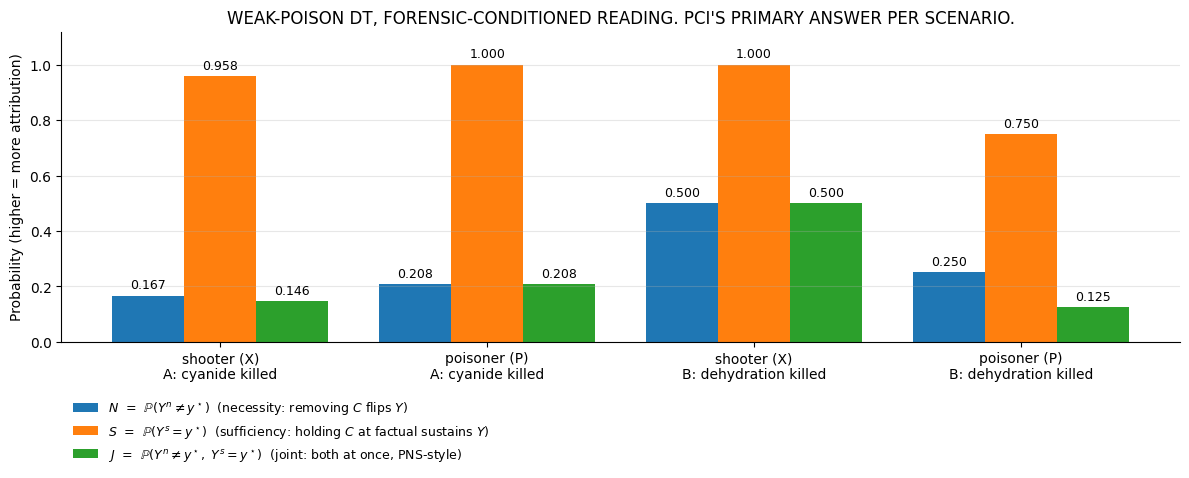

In [7]:
# Bar chart of the per-scenario (forensic-conditioned) reading -- this is the
# primary PCI answer for "who caused the death in scenario A / B".
fig, ax = plt.subplots(figsize=(12, 5))
group_labels = [
    name + " (" + letter + ")\n" + label
    for label, letter, name, *_ in forensic_manual_rows
]
x_pos = np.arange(len(forensic_manual_rows))
width = 0.27
N_vals = [r[3] for r in forensic_manual_rows]
S_vals = [r[4] for r in forensic_manual_rows]
J_vals = [r[5] for r in forensic_manual_rows]
ax.bar(
    x_pos - width,
    N_vals,
    width,
    label=r"$N$  =  $\mathbb{P}(Y^n \neq y^\star)$  (necessity: removing $C$ flips $Y$)",
    color="#1f77b4",
)
ax.bar(
    x_pos,
    S_vals,
    width,
    label=r"$S$  =  $\mathbb{P}(Y^s = y^\star)$  (sufficiency: holding $C$ at factual sustains $Y$)",
    color="#ff7f0e",
)
ax.bar(
    x_pos + width,
    J_vals,
    width,
    label=r"$J$  =  $\mathbb{P}(Y^n \neq y^\star,\ Y^s = y^\star)$  (joint: both at once, PNS-style)",
    color="#2ca02c",
)
ax.set_xticks(x_pos)
ax.set_xticklabels(group_labels, fontsize=10)
ax.set_ylabel("Probability (higher = more attribution)")
ax.set_title(
    "WEAK-POISON DT, FORENSIC-CONDITIONED READING. PCI'S PRIMARY ANSWER PER SCENARIO."
)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=9, loc="upper left", bbox_to_anchor=(0.0, -0.15), frameon=False)
ax.grid(axis="y", alpha=0.3)
for container_idx, vals in enumerate([N_vals, S_vals, J_vals]):
    for rect, v in zip(ax.containers[container_idx], vals):
        ax.annotate(
            f"{v:.3f}",
            xy=(rect.get_x() + rect.get_width() / 2, v),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

**Reading (weak-poison).** Framework and manual agree on all three
quantities within Monte Carlo noise. PCI's joint responsibility correctly
points to the **operative cause** in each scenario:

| Scenario | $J_{\text{shooter}}$ | $J_{\text{poisoner}}$ | Verdict |
|---|---|---|---|
| A: cyanide killed | $\approx 0.146$ | $\mathbf{\approx 0.208}$ | poisoner |
| B: dehydration killed | $\mathbf{\approx 0.500}$ | $\approx 0.125$ | shooter |

**Interpreting these absolute values.**

- **Sum-normalised share** (within scenario): the operative cause holds ~59%
  in A and ~80% in B. The asymmetry between A and B is the conceptual
  point of the weak-poison example: the poisoner's path is unreliable
  ($\xi = 0.1$), so even in their own scenario they get less of a share
  than the shooter does in B.
- **Max-configuration ratio**: both operative causes reach $J = 1$ in their
  own scenario, so what separates them is how many setups get there. The
  shooter in B hits $J = 1$ in four of the eight witness setups
  ($T = \emptyset, \{c\}, \{V_C\}, \{c, V_C\}$), which is what lifts the
  average to $0.500$. The poisoner in A hits it in one setup only,
  $T = \{d\}$, worth $\Gamma$-weight $1/12$; most of his $0.208$ comes from
  the empty witness set at $J = 0.5$.
- The result reflects the asymmetry built into the model: the shooter's
  path is deterministic, the poisoner's has a fatality coin. The coin does
  not cap what the best configuration can reach; it removes the other
  configurations that would otherwise reach it too.

## Summary

The notebook applies PCI under forensic conditioning: one pyro model per
scenario with the noise pinned at the scenario's forensic realisation;
`ThinSearchSampler` and a hand-rolled enumeration agree within Monte
Carlo noise on $N$, $S$, $J$ for both examples.

### Verdicts

| Example | Scenario | $J_{\text{shooter}}$ | $J_{\text{poisoner}}$ | Share (operative cause) |
|---|---|---|---|---|
| Basic DT | A (cyanide killed)     | $5/24 \approx 0.21$ | $\mathbf{1/3 \approx 0.33}$ | 62% |
| Basic DT | B (dehydration killed) | $\mathbf{1/3 \approx 0.33}$ | $5/24 \approx 0.21$ | 62% |
| Weak-poison | A | $\approx 0.146$ | $\mathbf{\approx 0.208}$ | 59% |
| Weak-poison | B | $\mathbf{\approx 0.500}$ | $\approx 0.125$ | 80% |

### Three intuitions PCI captures (weak-poison)

1. **Adding noise lowers the noisy cause's own responsibility.** Cyanide
   in A drops from $1/3$ (basic) to $\approx 0.21$ (weak). The cyanide
   step is now stochastic, so the sufficiency factor falls.
2. **Within a scenario, the operative cause still wins.** Weak-poison A:
   $J_P = 0.208 > J_X = 0.146$. The poisoner remains the responsible
   party in his own scenario.
3. **Reliable causes beat unreliable causes across scenarios.** Weak-
   poison: $J_X$ in B ($0.500$) $>$ $J_P$ in A ($0.208$). The
   deterministic dehydration path makes the shooter in B a textbook
   responsible cause; the stochastic cyanide path makes the poisoner in
   A a *real but unreliable* responsible cause.

### Where the numbers come from

The $J$ values are sums over witness configurations weighted by
cardinality-uniform $\Gamma$ (default of `sample_k_indices`). In the basic
DT the poisoner in A reaches $J = 1$ at $T = \{d\}$ (weight $1/6$) and
$J = 0.5$ at $T = \emptyset$ (weight $1/3$); those two contributions are
$1/6$ each and sum to the reported $1/3$. The weak-poison totals:

- Shooter in B: $J = 1$ in four of the eight setups
  ($T = \emptyset, \{c\}, \{V_C\}, \{c, V_C\}$). Averaged: $0.500$.
- Poisoner in A: $J = 1$ in one setup, $T = \{d\}$ (weight $1/12$), plus
  $J = 0.5$ at $T = \emptyset$. Averaged: $0.208$.

### Spec consistency

- intervention-based context-sensitivity via witnesses (sec2:253--257);
- non-cause suspect follows the SCM (sec3:451--462);
- $P_{\mathbf{U}}$ conditioned on **forensic** evidence (above $Y$ in the
  SCM), not on $Y$ itself (sec3:330--336 anti-pattern avoided);
- cardinality-uniform $\Gamma$ matches the framework's
  `sample_k_indices(weighting="cardinality")` default.